CREDIT CARD FRAUD DETECTION

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Load Dataset

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dataset Information

In [3]:
print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape : (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64


 Data Cleaning

 Remove duplicate rows

In [4]:
df = df.drop_duplicates()

print("\nDataset Shape After Cleaning:")
print(df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Dataset Shape After Cleaning:
(283726, 31)

Missing Values After Cleaning:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Data Visualization

In [5]:
sns.set_style("whitegrid")

 Fraud vs Genuine

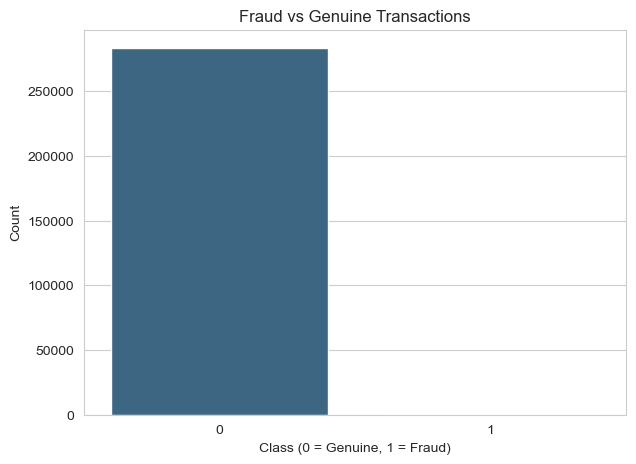

In [6]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Class',
    hue='Class',
    data=df,
    palette='viridis',
    legend=False
)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

Transaction Amount

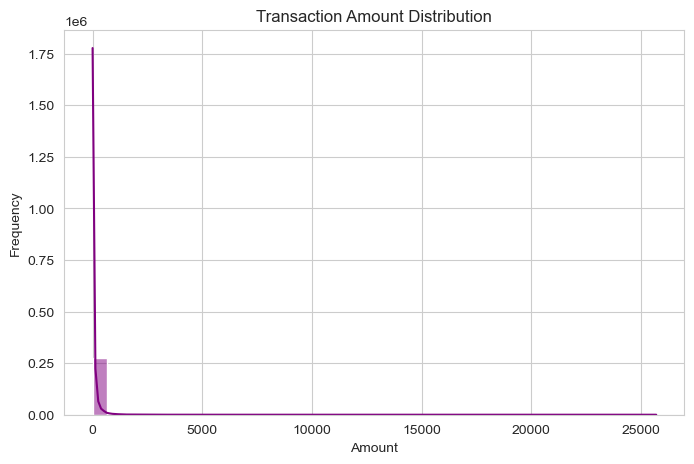

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Amount'],
    bins=40,
    kde=True,
    color='purple'
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

Correlation Heatmap

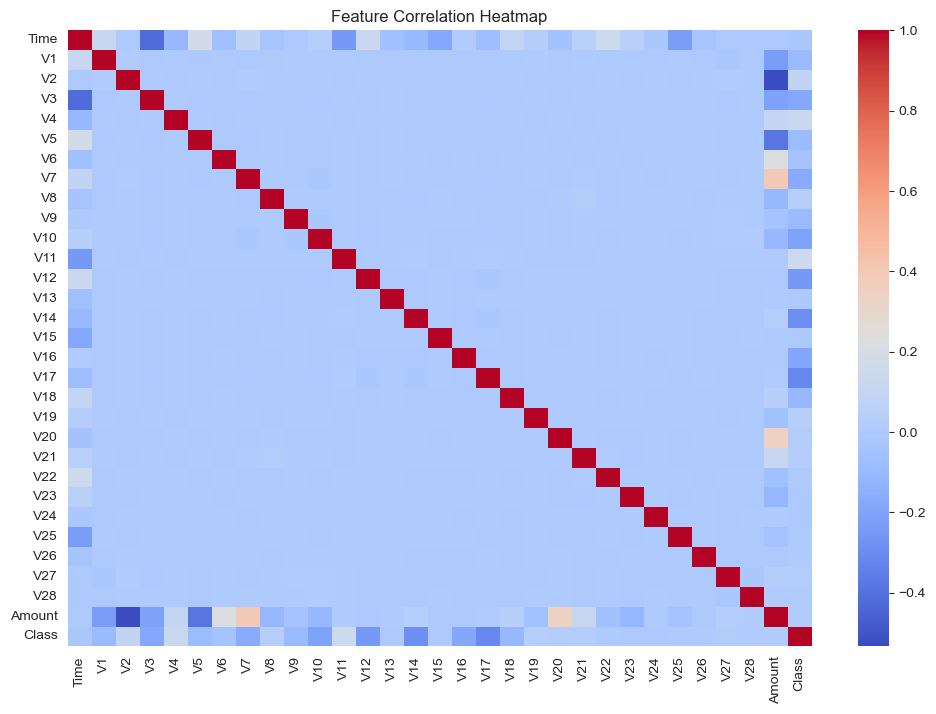

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

Feature Scaling

In [9]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(
    df[['Amount']]
)

Features and Target

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

 Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape : (226980, 30)
Testing Shape : (56746, 30)


Model Training

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


Prediction

In [13]:
y_pred = model.predict(X_test)

Model Evaluation

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy Score : 0.9990131463010609

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.71      0.68      0.70        95

    accuracy                           1.00     56746
   macro avg       0.86      0.84      0.85     56746
weighted avg       1.00      1.00      1.00     56746



Confusion Matrix

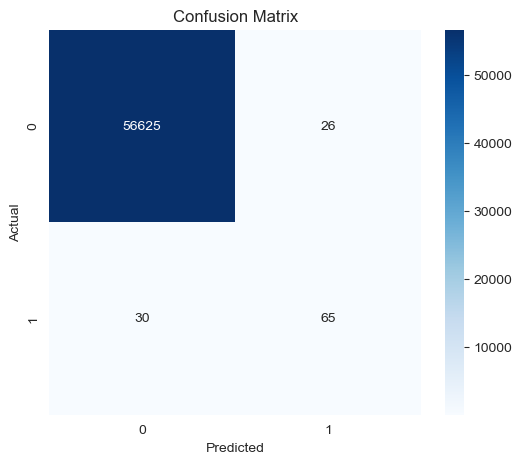

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Sample Prediction

In [16]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 0:
    print("\nPrediction : Genuine Transaction")
else:
    print("\nPrediction : Fraud Transaction")


Prediction : Genuine Transaction
